# **Diagnosing infeasible problems**

***diagnose_infeasible.ipynb***

In this example, we demonstrate how to use Irreducible Infeasible Sets (IIS) to programmatically identify and diagnose constraints and bounds causing infeasibility in optimization problems. For diagnosing unbounded LP problems using primal rays, see [diagnose_unbounded.ipynb](diagnose_unbounded.ipynb).

&copy; Copyright 2025-2026 Fair Isaac Corporation. The use of this example is subject to [legal and license requirements](https://github.com/fico-xpress/python-notebooks#legal-and-license-requirements).

In [ ]:
# Install the necessary packages
%pip install -q xpress pandas matplotlib

## How to diagnose an infeasible problem

When the solver identifies a problem as infeasible, it means there is no solution that satisfies all constraints simultaneously. The challenge is identifying *which* constraints are in conflict.

An **Irreducible Infeasible Set (IIS)** is a minimal subset of constraints and variable bounds that is itself infeasible, but that subset becomes feasible if any single constraint or bound within it is removed. Note that removing one element from an IIS only resolves that particular infeasibility — the overall problem may still be infeasible due to other independent IIS.

An **IIS isolation** (or sub-IIS isolation) is a special constraint or bound within an IIS. While removing *any* constraint from an IIS makes that IIS feasible, removing an isolation constraint will also *not increase* infeasibilities elsewhere—that is, it won't make other independent IIS worse. Isolations thus indicate the likely root cause of each independent infeasibility and suggest which constraint to drop or modify first.

To programmatically diagnose infeasible problems:

1. **Check the solution status** after solving: `prob.attributes.solstatus == xp.SolStatus.INFEASIBLE`
2. **Generate the first IIS**: [`prob.firstIIS()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.firstIIS.html) returns 0 if successful
3. **Get IIS statistics**: [`prob.IISStatus()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.IISStatus.html) returns the number of IIS found, rows, columns, and infeasibility measures
4. **Retrieve IIS details**: [`prob.getIISData()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.getIISData.html) returns the specific rows and bounds in the IIS
5. **Find isolations** (optional): [`prob.IISIsolations()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.IISIsolations.html) identifies constraints that can be removed without worsening other infeasibilities

**Important notes:**
- A problem may have multiple independent IIS. Fixing one IIS may not make the problem feasible if other IIS exist.
- Use [`prob.IISAll()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.IISAll.html) to find all independent IIS, or iterate with [`prob.nextIIS()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.nextIIS.html). **Note:** Multiple IIS is supported only for LP problems; for MIP and NLP, only a single IIS will be computed with `IISAll()`.
- For MIP problems, IIS generation can be computationally expensive. Use the [`IISOPS`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/HTML/IISOPS.html) control to disable sets of restrictions for better performance (e.g., removing integer restrictions from binaries is rarely practical for diagnosis).
- The isolation procedure is also computationally expensive and is not always able to find isolations
- If a time limit or interruption (Ctrl+C) occurs during IIS computation, an infeasible subsystem may be returned that is not irreducible (i.e., it may be larger than a true IIS)

IIS analysis is supported for all problem types that can be solved to infeasibility: **LP, MIP, QP, QCQP, and NLP** (nonlinear may require a global solver license)

## Helper function for diagnosing infeasibility

The following helper function `diagnose_infeasible()` encapsulates the logic for diagnosing infeasible problems using IIS, similar to how we use primal rays for unbounded problems.

**What it does:**
1. Checks if the problem status is `INFEASIBLE`
2. Generates IIS using [`firstIIS()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.firstIIS.html) or [`IISAll()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.IISAll.html) to find all independent IIS
3. Retrieves IIS statistics and detailed data for each IIS
4. Optionally finds IIS isolations to identify likely causes
5. Returns a structured dictionary with diagnostic information and a human-readable report

**Parameters:**
- `find_isolations` (default `True`): Whether to compute isolations for each IIS
- `find_all` (default `False`): If `True`, finds all independent IIS; if `False`, only finds the first one

The return value includes `'is_infeasible': Boolean` and `'iis_list': List[dict]` to enable programmatic handling.

Run the code cell as we will call this helper function multiple times in the examples that follow.

**Feel free to copy the `diagnose_infeasible` helper function and use it in your own problem(s)!**

In [ ]:
import xpress as xp

def diagnose_infeasible(prob: xp.problem, find_isolations: bool = True, find_all: bool = False) -> dict:
    """
    Diagnose an infeasible problem by generating and analyzing IIS.
    
    Parameters:
        prob: An Xpress problem that has been solved and found infeasible.
        find_isolations: Whether to identify IIS isolations (constraints that
                        if removed would resolve the infeasibility without 
                        worsening other independent IIS).
        find_all: If True, find all independent IIS using IISAll(). 
                 If False (default), only find the first IIS.
    
    Returns:
        A dictionary containing:
        - 'is_infeasible': Boolean indicating if problem is infeasible
        - 'iis_found': Boolean indicating if an IIS was successfully generated
        - 'iis_status': The IISSOLSTATUS value:
            0 = unstarted (xp.IISSolStatus.UNSTARTED - license/input error)
            1 = feasible (xp.IISSolStatus.FEASIBLE - no IIS found)
            2 = completed (xp.IISSolStatus.COMPLETED - normal termination)
            3 = unfinished (xp.IISSolStatus.UNFINISHED - returned subsystem may not be irreducible)
        - 'num_iis': Number of IIS found
        - 'iis_list': List of dictionaries, one per IIS, each containing:
            - 'iis_number': The IIS index (1-based)
            - 'iis_constraints': List of constraint objects for rows in the IIS
            - 'iis_variables': List of variable objects for bounds in the IIS
            - 'constraint_types': Type/violation side for each entry in iis_constraints:
                'L' = relax the <= side, 'G' = relax the >= side, 'E' = relax constraint entirely
                '1' = SOS1 constraint, '2' = SOS2 constraint, 'W' = piecewise linear,
                'X' = general constraint, 'I' = indicator constraint
                Note: for SOS/pwl/gencons/indicators, getConstraint() may not resolve correctly
            - 'bound_types': How to relax each bound to resolve the conflict:
                'L' = relax lower bound, 'U' = relax upper bound, 'I' = relax integrality
            - 'isolation_constraints': Constraint objects identified as isolations
            - 'isolation_variables': Variable objects identified as isolations
        - 'message': Human-readable diagnostic message
    """
    result = {
        'is_infeasible': False,
        'iis_found': False,
        'iis_status': 0,
        'num_iis': 0,
        'iis_list': [],
        'message': ''
    }
    
    # Check solution status
    if prob.attributes.solstatus != xp.SolStatus.INFEASIBLE:
        result['message'] = f"Problem is not infeasible. Solution status: {prob.attributes.solstatus.name}"
        return result
    
    result['is_infeasible'] = True
    
    # Generate IIS - either all or just the first.
    # Note: IISAll() always returns None; use IISSOLSTATUS to check success.
    if find_all:
        prob.IISAll()
    else:
        prob.firstIIS(1)
    
    # Check IISSOLSTATUS to see if IIS computation completed or was interrupted.
    # This is the correct check for both IISAll() and firstIIS(), since IISAll() always returns None.
    # Values: UNSTARTED=0 (error), FEASIBLE=1 (no IIS), COMPLETED=2, UNFINISHED=3 (interrupted)
    iis_sol_status = prob.attributes.iissolstatus
    result['iis_status'] = iis_sol_status
    
    if iis_sol_status == xp.IISSolStatus.UNSTARTED:
        result['message'] = "IIS computation failed (license or input error)."
        return result
    
    if iis_sol_status == xp.IISSolStatus.FEASIBLE:
        result['message'] = "No IIS found - problem may actually be feasible."
        return result
    
    result['iis_found'] = True
    
    # Build diagnostic message header
    lines = ["INFEASIBLE PROBLEM DIAGNOSIS", "=" * 45]
    if iis_sol_status == xp.IISSolStatus.UNFINISHED:  # Partial IIS available but may not be minimal
        lines.append("WARNING: IIS computation was interrupted - the returned subsystem may not be irreducible (larger than a true IIS)")
    
    # Get IIS statistics
    numiis, num_rows, num_cols, sum_inf, num_inf = prob.IISStatus()
    result['num_iis'] = numiis
    lines.append(f"Number of independent IIS found: {numiis}")
    lines.append("")
    
    # Process each IIS
    for iis_num in range(1, numiis + 1):
        # Compute isolations before getIISData to ensure isolation information is included
        if find_isolations:
            prob.IISIsolations(iis_num)
        
        # Single call to getIISData - isolation data is included if IISIsolations was called above
        miisrow, miiscol, constrainttype, colbndtype, duals, rdcs, \
            isolationrows, isolationcols = prob.getIISData(iis_num)
        
        constraints = prob.getConstraint(miisrow)
        variables = prob.getVariable(miiscol)
        iis_info = {
            'iis_number': iis_num,
            'iis_constraints': constraints,
            'iis_variables': variables,
            'constraint_types': list(constrainttype),
            'bound_types': list(colbndtype),
            'isolation_constraints': [constraints[i] for i in range(len(miisrow)) if isolationrows[i] == 1],
            'isolation_variables': [variables[i] for i in range(len(miiscol)) if isolationcols[i] == 1],
        }
        
        result['iis_list'].append(iis_info)
        
        # Report rows (constraints) in the IIS
        lines.append(f"IIS {iis_num}: {len(miisrow)} rows, {len(miiscol)} bounds")
        if len(miisrow) > 0:
            con_names = [c.name for c in iis_info['iis_constraints']]
            nw = max(22, max(len(n) for n in con_names) + 2)
            lines.append(f"{'Row':<8} {'Name':<{nw}} {'Type':<8} {'Isolation':<10}")
            lines.append("-" * (8 + 1 + nw + 1 + 8 + 1 + 10))
            for i, row_idx in enumerate(miisrow):
                is_isolation = "YES" if isolationrows[i] == 1 else ""
                lines.append(f"{row_idx:<8} {con_names[i]:<{nw}} {constrainttype[i]:<8} {is_isolation:<10}")
        
        # Report variable bounds in the IIS
        if len(miiscol) > 0:
            var_names = [v.name for v in iis_info['iis_variables']]
            vw = max(22, max(len(n) for n in var_names) + 2)
            lines.append("")
            lines.append(f"{'Col':<8} {'Variable':<{vw}} {'BndType':<10} {'Isolation':<10}")
            lines.append("-" * (8 + 1 + vw + 1 + 10 + 1 + 10))
            for i, col_idx in enumerate(miiscol):
                is_isolation = "YES" if isolationcols[i] == 1 else ""
                lines.append(f"{col_idx:<8} {var_names[i]:<{vw}} {colbndtype[i]:<10} {is_isolation:<10}")

    if numiis > 1:
        lines.append(f"Note: Problem has {numiis} independent IIS. All must be resolved for feasibility.")
    
    result['message'] = "\n".join(lines)
    return result

**Advanced control with [`IISOPS`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/HTML/IISOPS.html)** For IIS computation, you can use the [`IISOPS`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/HTML/IISOPS.html) control to exclude certain constraint types or integrality requirements from consideration. 

With this control, you can prevent equalities from being included in the IIS (since relaxing them would make the model fundamentally wrong) or exclude integrality requirements on binary variables.

For example, to protect binary and general integer restrictions from being dropped:

```python
# Bit 0 = keep binary integralities, bit 4 = keep general integer integralities
# 2^0 + 2^4 = 1 + 16 = 17
prob.controls.iisops = 17
```

Other useful bits: bit 5 (`+32`) to also protect equality constraints, bit 3 (`+8`) to protect all variable bounds. Combine by summing the bit values (e.g. `iisops = 17 + 32 = 49` to protect binaries, integers, and equalities).

## Example 1: Basic infeasible LP

We start with a simple LP where the constraints directly conflict with each other. This example demonstrates how to detect infeasibility and use the helper function to identify the conflicting constraints.

**Note:** For simple cases like this, Xpress **presolve** will detect and report the infeasibility directly (as shown in the output below). However, programmatic IIS analysis is still valuable for:
- Automated workflows that need to identify conflicts without parsing log messages
- More complex models where presolve may not pinpoint the exact cause
- Integrating infeasibility diagnosis into optimization applications

$$
\begin{align*}
\text{max} \quad & x + y \\
\text{subject to} \quad & x + y \leq 10 \\
& x + y \geq 20 \\
& 0 \leq x \leq 10 \\
& 0 \leq y \leq 5
\end{align*}
$$

**Issues:** The constraints $x + y \leq 10$ and $x + y \geq 20$ directly conflict. Additionally, the variable bounds cap $x + y$ at $10 + 5 = 15$, which also makes satisfying $x + y \geq 20$ impossible.

In [ ]:
# Create a simple infeasible LP problem
p1 = xp.problem(name="InfeasibleExample")

# Add decision variables
x = p1.addVariable(name="x", lb=0, ub=10)
y = p1.addVariable(name="y", lb=0, ub=5)

# Set objective
p1.setObjective(x + y, sense=xp.maximize)

# Add conflicting constraints
upper_limit = p1.addConstraint(x + y <= 10, name="upper_limit")

lower_limit = p1.addConstraint(x + y >= 20, name="lower_limit")  # Conflicts with above!

# Solve
p1.controls.outputlog = 0
p1.optimize()

print(f"Solution status: {p1.attributes.solstatus.name}")

Solution status: INFEASIBLE


### Diagnosing with the helper function

Now we use the `diagnose_infeasible()` helper function to identify which constraints are causing the infeasibility.

In [ ]:
# Use the helper function to diagnose
diagnosis = diagnose_infeasible(p1, find_isolations=True, find_all=True)
print(diagnosis['message'])

INFEASIBLE PROBLEM DIAGNOSIS
Number of independent IIS found: 1

IIS 1: 1 rows, 2 bounds
Row      Name                   Type     Isolation 
---------------------------------------------------
1        lower_limit            G        YES       

Col      Variable               BndType    Isolation 
-----------------------------------------------------
0        x                      U                    
1        y                      U                    


The diagnosis reveals that a single IIS was found, with two types of entries:

- **`lower_limit`** (**row**, marked *Isolation*): removing it dissolves this IIS **and** does not increase infeasibilities elsewhere — `{upper_limit, x.ub, y.ub}` is trivially feasible (e.g. x=0, y=0). It is the isolation in this IIS — the most actionable element to modify.
- **`x.ub`, `y.ub`** (**bounds**, *not* isolations): removing either one also dissolves this IIS (that is precisely why they are in it — by definition, removing any IIS element makes that IIS feasible). However, doing so increases infeasibilities outside: `upper_limit` now pairs with `lower_limit` into a new infeasible subset. The infeasibility shifted rather than resolved.

**Note:** `IISAll()` or `firstIIS()` find **independent** (non-overlapping) IIS, i.e. each constraint can appear in at most one. Both `{lower_limit, x.ub, y.ub}` and `{upper_limit, lower_limit}` are valid infeasible subsets, but they overlap on `lower_limit`. The solver reported `{lower_limit, x.ub, y.ub}`. The exact choice between overlapping candidates is implementation-dependent (for LP, it follows from the dual basis; for MIP, from the deletion filter order) and is not guaranteed to favour any particular size measure.

In [ ]:
# Relax the bounds to infinity and re-diagnose
x.ub = xp.infinity
y.ub = xp.infinity
p1.optimize()

diagnosis_no_bounds = diagnose_infeasible(p1, find_isolations=True, find_all=True)
print(diagnosis_no_bounds['message'])

INFEASIBLE PROBLEM DIAGNOSIS
Number of independent IIS found: 1

IIS 1: 2 rows, 0 bounds
Row      Name                   Type     Isolation 
---------------------------------------------------
0        upper_limit            L        YES       
1        lower_limit            G        YES       


Setting `x.ub = y.ub = inf` dissolves `{lower_limit, x.ub, y.ub}`, freeing `lower_limit` to appear in a new search. The solver now finds `{upper_limit, lower_limit}` as the only remaining infeasible subset i.e. the problem is still infeasible. The isolation correctly identifies `lower_limit` as the constraint whose removal resolves all infeasibility cleanly.

### Fixing the infeasible problem

Based on the new diagnosis, we can fix the problem by relaxing one of the conflicting constraints. Here we modify the lower bound constraint to be compatible with the upper bound.

We change the RHS from 20 to 5, which means the constraint becomes $x + y \geq 5$ instead of $x + y \geq 20$. The value 5 is chosen to be less than the upper limit of 10, making both constraints satisfiable. Any value in the range $[0, 10]$ would work.

In [ ]:
# Fix by directly modifying the RHS of the conflicting constraint via the constraint object
lower_limit.rhs = 5  # x + y >= 5 instead of >= 20

# Re-solve
p1.optimize()

print(f"Solution status after fix: {p1.attributes.solstatus.name}")
if p1.attributes.solstatus == xp.SolStatus.OPTIMAL:
    print(f"Optimal objective value: {p1.attributes.objval:.4f}")
    print(f"Solution: x = {p1.getSolution(x):.4f}, y = {p1.getSolution(y):.4f}")

Solution status after fix: OPTIMAL
Optimal objective value: 10.0000
Solution: x = 10.0000, y = 0.0000


## Example 2: Portfolio optimization with conflicting requirements

This example demonstrates a more realistic scenario where business requirements create an infeasible model. A portfolio optimization problem with diversification constraints across regions and sectors can become infeasible when the constraints are too restrictive.

**Problem:** Select shares from a portfolio to maximize expected return, subject to:
- Risk limits on high-risk stocks
- Diversification across geographical regions (minimum and maximum per region)
- Diversification across industry sectors (maximum per sector)
- Budget allocation constraints

**Data**: We use the `folio5.csv` dataset containing 50 shares with their expected returns, risk classification, geographical location, and industry sector. For a more comprehensive treatment of portfolio optimization with Pandas integration, see [portfolio_pandas.ipynb](portfolio_pandas.ipynb).

The code cell below loads the data and defines the model parameters. Note the very restrictive `MaxSector = 0.1` (10%) which will cause infeasibility.

In [ ]:
import pandas as pd

# Input parameters
MaxHighRisk = 1/3      # Max 33% in high-risk stocks
MinRegion = 0.1        # Min 10% per region
MaxRegion = 0.2        # Max 20% per region  
MaxSector = 0.1        # Max 10% per sector - this is very restrictive!
MinPerShare = 0.1      # Min 10% if we invest in a share
MaxPerShare = 0.2      # Max 20% per share
MaxShares = 10         # Maximum number of different shares

# Read data from csv
Shares = pd.read_csv("data/folio5.csv")
REGIONS = Shares['Location'].dropna().unique().tolist()
SECTORS = Shares['Sector'].unique().tolist()

print(f"Portfolio has {len(Shares)} shares across {len(REGIONS)} regions and {len(SECTORS)} sectors")
print(f"\nRegions: {REGIONS}")
print(f"Sectors: {SECTORS}")

Portfolio has 50 shares across 3 regions and 8 sectors

Regions: ['EU', 'USA', 'APAC']
Sectors: ['bonds', 'technology', 'entertainment', 'telecom', 'food', 'construction', 'manufacturing', 'finance']


### Mathematical formulation

Let $\mathcal{S}$ be the set of available shares, $\mathcal{R}$ be the set of geographical regions, and $\mathcal{T}$ be the set of industry sectors. For each share $i \in \mathcal{S}$, let $RET_i$ be the expected return and $RISK_i$ indicate whether the share is high-risk (boolean).

**Decision variables:**
- $frac_i \in [0, 1]$: fraction of budget allocated to share $i$
- $buy_i \in \{0, 1\}$: 1 if share $i$ is selected, 0 otherwise

**Objective:** Maximize expected return
$$\max \sum_{i \in \mathcal{S}} RET_i \cdot frac_i$$

**Subject to:**

Limit high-risk stock allocation:
$$\sum_{i \in \mathcal{S}: RISK_i = 1} frac_i \leq \text{MaxHighRisk}$$

Regional diversification (for each region $r \in \mathcal{R}$):
$$\text{MinRegion} \leq \sum_{i \in \mathcal{S}: Region_i = r} frac_i \leq \text{MaxRegion}$$

Sector diversification (for each sector $t \in \mathcal{T}$):
$$\sum_{i \in \mathcal{S}: Sector_i = t} frac_i \leq \text{MaxSector}$$

Fully invested portfolio:
$$\sum_{i \in \mathcal{S}} frac_i = 1$$

Maximum number of shares:
$$\sum_{i \in \mathcal{S}} buy_i \leq \text{MaxShares}$$

Linking constraints (for each share $i \in \mathcal{S}$):
$$\text{MinPerShare} \cdot buy_i \leq frac_i \leq \text{MaxPerShare} \cdot buy_i$$

**Issue**: The combination of sector limits (max 10% per sector) with regional requirements can make the problem infeasible when there aren't enough shares in each region that span different sectors.

In [ ]:
# Create Xpress problem and variables
p2 = xp.problem("portfolio")

# Decision variables - Using Pandas integration with dtype='xpressobj'
# This enables vectorized Pandas operations for cleaner model building
Shares['fraction'] = pd.Series(
    p2.addVariables(len(Shares), vartype=xp.continuous, name='fraction'),
    dtype='xpressobj'
)
Shares['buy'] = pd.Series(
    p2.addVariables(len(Shares), vartype=xp.binary, name='buy'),
    dtype='xpressobj'
)

# Objective: maximize expected total return using Pandas vectorized operation
p2.setObjective((Shares['Return'] * Shares['fraction']).sum(), sense=xp.maximize)

# Constraint 1: Limit high-risk stocks using boolean indexing
p2.addConstraint(Shares[Shares['Risk']]['fraction'].sum() <= MaxHighRisk, name="max_high_risk")

# Constraint 2: Regional diversification
for r in REGIONS:
    region_shares = Shares[Shares['Location'] == r]
    p2.addConstraint(region_shares['fraction'].sum() >= MinRegion, name=f"min_region_{r}")
    p2.addConstraint(region_shares['fraction'].sum() <= MaxRegion, name=f"max_region_{r}")

# Constraint 3: Sector diversification
for t in SECTORS:
    sector_shares = Shares[Shares['Sector'] == t]
    p2.addConstraint(sector_shares['fraction'].sum() <= MaxSector, name=f"max_sector_{t}")

# Constraint 4: Spend all capital
p2.addConstraint(Shares['fraction'].sum() == 1, name="fully_invested")

# Constraint 5: Limit total number of assets
p2.addConstraint(Shares['buy'].sum() <= MaxShares, name="max_shares")

# Constraint 6: Linking decision variables - prefix generates min_alloc_(0) .. min_alloc_(49)
p2.addConstraint(Shares['fraction'] >= MinPerShare * Shares['buy'], name="min_alloc_")
p2.addConstraint(Shares['fraction'] <= MaxPerShare * Shares['buy'], name="max_alloc_")

# Solve
p2.controls.outputlog = 0
p2.optimize()

print(f"Solution status: {p2.attributes.solstatus.name}")

Solution status: INFEASIBLE


### Diagnosing the portfolio infeasibility

The problem is infeasible because the sector limits (max 10% each) combined with regional minimum requirements cannot all be satisfied simultaneously. Let's use IIS to identify the conflicting constraints.

In [ ]:
# Diagnose the infeasibility
diagnosis = diagnose_infeasible(p2, find_isolations=True, find_all=False)
print(diagnosis['message'])

# Export the first IIS to a file for detailed inspection
p2.writeIIS(iis=1, filename="portfolio_iis", filetype=0, flags="l")
print("\nIIS exported to portfolio_iis.lp for detailed inspection")

INFEASIBLE PROBLEM DIAGNOSIS
Number of independent IIS found: 1

IIS 1: 9 rows, 0 bounds
Row      Name                       Type     Isolation 
-------------------------------------------------------
7        max_sector_bonds           L        YES       
8        max_sector_technology      L                  
9        max_sector_entertainment   L                  
10       max_sector_telecom         L                  
11       max_sector_food            L        YES       
12       max_sector_construction    L        YES       
13       max_sector_manufacturing   L        YES       
14       max_sector_finance         L        YES       
15       fully_invested             G        YES       

IIS exported to portfolio_iis.lp for detailed inspection


### Fixing by relaxing sector constraints

The IIS analysis shows that the sector constraints are likely causing the infeasibility. By increasing the maximum allocation per sector from 10% to 20%, we can make the problem feasible.

In [ ]:
# Fix: Relax the sector constraints by increasing the RHS
# The IIS contains max_sector_* constraints (all 'L' type) that are too restrictive.
# We'll increase MaxSector from 0.1 to 0.2 for all sector limits in the IIS.

new_max_sector = 0.2
iis_data = diagnosis['iis_list'][0]  # Get first IIS data
for i, con in enumerate(iis_data['iis_constraints']):
    # Get constraint type - only modify 'L' (<=) constraints that are sector limits
    if iis_data['constraint_types'][i] == 'L':
        con.rhs = new_max_sector

# Re-solve
p2.optimize()

print(f"Solution status after fix: {p2.attributes.solstatus.name}")
if p2.attributes.solstatus == xp.SolStatus.OPTIMAL:
    print(f"Optimal expected return: {p2.attributes.objval:.2f}%")
    
    # Extract solution directly into DataFrame
    Shares['solution'] = p2.getSolution(Shares['fraction'])
    
    # Show selected shares using Pandas filtering
    selected = Shares[Shares['solution'] > 0.001]
    print(f"\nSelected portfolio:")
    for share in selected.index:
        print(f"  {share}: {selected.loc[share, 'solution']*100:.1f}%")
    
    # Store solution for comparison later
    sol_example2 = Shares['solution'].values.copy()

Solution status after fix: OPTIMAL
Optimal expected return: 18.49%

Selected portfolio:
  2: 10.0%
  12: 13.3%
  23: 20.0%
  25: 16.7%
  31: 20.0%
  43: 20.0%


## Example 3: Automatic infeasibility repair

When manually identifying and fixing infeasibilities is difficult, Xpress provides the [`repairWeightedInfeas()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.repairWeightedInfeas.html) utility (and its simplified wrapper [`repairInfeas()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.repairInfeas.html)). This function automatically relaxes constraints based on user-defined preferences to find a feasible solution.

**How it works:**
1. Users assign **preferences** to constraints indicating willingness to relax them (higher = more willing, 0 = cannot relax)
2. **Phase 1**: Finds a relaxed solution that minimally violates constraints based on preferences
3. **Phase 2**: Optimizes the original objective while keeping violations within the Phase 1 bounds

**Note**: For `repairInfeas` to succeed, there must be enough freedom to relax constraints. If only certain constraint types can be relaxed but the infeasibility involves other types (that cannot be relaxed), the repair may still fail.

In [ ]:
# Recreate the infeasible portfolio problem
p3 = xp.problem("portfolio_repair")

# Decision variables - Using Pandas integration with dtype='xpressobj'
Shares['fraction'] = pd.Series(
    p3.addVariables(len(Shares), vartype=xp.continuous, name='fraction'),
    dtype='xpressobj'
)
Shares['buy'] = pd.Series(
    p3.addVariables(len(Shares), vartype=xp.binary, name='buy'),
    dtype='xpressobj'
)

# Objective: maximize expected total return using Pandas vectorized operation
p3.setObjective((Shares['Return'] * Shares['fraction']).sum(), sense=xp.maximize)

# All constraints (same as before with restrictive MaxSector = 0.1)
MaxSector_strict = 0.1

p3.addConstraint(Shares[Shares['Risk']]['fraction'].sum() <= MaxHighRisk, name="max_high_risk")

for r in REGIONS:
    region_shares = Shares[Shares['Location'] == r]
    p3.addConstraint(region_shares['fraction'].sum() >= MinRegion, name=f"min_region_{r}")
    p3.addConstraint(region_shares['fraction'].sum() <= MaxRegion, name=f"max_region_{r}")

for t in SECTORS:
    sector_shares = Shares[Shares['Sector'] == t]
    p3.addConstraint(sector_shares['fraction'].sum() <= MaxSector_strict, name=f"max_sector_{t}")

p3.addConstraint(Shares['fraction'].sum() == 1, name="fully_invested")
p3.addConstraint(Shares['buy'].sum() <= MaxShares, name="max_shares")
p3.addConstraint(Shares['fraction'] >= MinPerShare * Shares['buy'], name="min_alloc_")
p3.addConstraint(Shares['fraction'] <= MaxPerShare * Shares['buy'], name="max_alloc_")

# Verify it's infeasible
p3.controls.outputlog = 0
p3.optimize()
print(f"Initial status: {p3.attributes.solstatus.name}")

Initial status: INFEASIBLE


### Understanding `repairWeightedInfeas()` parameters

The [`repairWeightedInfeas()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.repairWeightedInfeas.html) function accepts per-row preference arrays to fine-tune which constraints can be relaxed. Here's what each parameter defines:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `lepref` | `list[float]` | Per-row preference for relaxing the **less-than-or-equal** side — `0` protects a row, higher values make relaxation cheaper (weight = 1/preference) |
| `gepref` | `list[float]` | Per-row preference for relaxing the **greater-than-or-equal** side — `0` protects a row |
| `lbpref` | `list[float]` | Per-column preference for relaxing **lower bounds** — `0` means never relax |
| `ubpref` | `list[float]` | Per-column preference for relaxing **upper bounds** — `0` means never relax |
| `phase2` | `'o'` | Use the **original objective** sense in Phase 2 optimization |
| `delta` | `0` | Relaxation multiplier for Phase 2 (0 = stay within Phase 1 bounds) |
| `flags` | `'g'` | Flags passed to `problem.optimize` |

> **Note:** These are penalty *coefficients*, not binary flags — you can use values like `lepref=2, gepref=0.5` to make less-than-or-equal constraints 4 times as preferred to relax as greater-than-or-equal ones.

### Guidance: Which constraints should be relaxed?

When deciding which constraints to allow relaxation, consider their nature:

**Good candidates for relaxation** (set preference to 1 or higher):
- **Policy constraints** involving external parameters (e.g., sector limits, budget caps)
- **Soft business rules** that can be adjusted (e.g., diversification requirements)
- **Inequality constraints** derived from data that may have uncertainty

**Should NOT be relaxed** (keep preference at 0):
- **Balance constraints** (e.g., conservation of flow, accounting identities)
- **Definition constraints** that would make the model mathematically incorrect
- **Physical constraints** that cannot be violated in reality
- **Variable bounds** that define the domain of feasible values

**Our choice in this example**: We pass per-row preference arrays for `lepref` and `gepref`, setting `1` for inequality constraints (sector limits, regional requirements — soft business rules that can be relaxed) and `0` for equality constraints (such as `sum(fraction) == 1` — a balance constraint that must not be violated). Variable bounds are also kept fixed (arrays of zeros for `lbpref` and `ubpref`).

In [ ]:
# Build per-row preference arrays — protect equality constraints from relaxation
n_rows = p3.attributes.rows
n_cols = p3.attributes.cols
row_types = p3.getRowType(0, n_rows - 1)
le_prefs = [0.0 if t == 'E' else 1.0 for t in row_types]
ge_prefs = [0.0 if t == 'E' else 1.0 for t in row_types]
lb_prefs = [0.0] * n_cols  # Do not relax lower bounds
ub_prefs = [0.0] * n_cols  # Do not relax upper bounds

p3.repairWeightedInfeas(
    lepref=le_prefs,    # Per-row: 1 for inequalities, 0 for equalities
    gepref=ge_prefs,    # Per-row: 1 for inequalities, 0 for equalities
    lbpref=lb_prefs,
    ubpref=ub_prefs,
    phase2='o',
    delta=0,
    flags='g'
)

# Extract solution directly into DataFrame
Shares['solution'] = p3.getSolution(Shares['fraction'])

# Show selected shares using Pandas filtering
selected = Shares[Shares['solution'] > 0.001]
print(f"\nRepaired portfolio (with relaxed constraints):")
total_allocated = selected['solution'].sum()
for share in selected.index:
    print(f"  {share}: {selected.loc[share, 'solution']*100:.1f}%")
print(f"\nTotal allocated: {total_allocated*100:.1f}%")

# Store solution for comparison later
sol_example3 = Shares['solution'].values.copy()


Repaired portfolio (with relaxed constraints):
  2: 10.0%
  13: 10.0%
  17: 10.0%
  24: 16.7%
  25: 20.0%
  31: 10.0%
  35: 10.0%
  43: 13.3%

Total allocated: 100.0%


### Comparing the two solutions

Let's visualize how the two approaches (manual constraint relaxation vs automatic repair) resulted in different portfolio allocations.

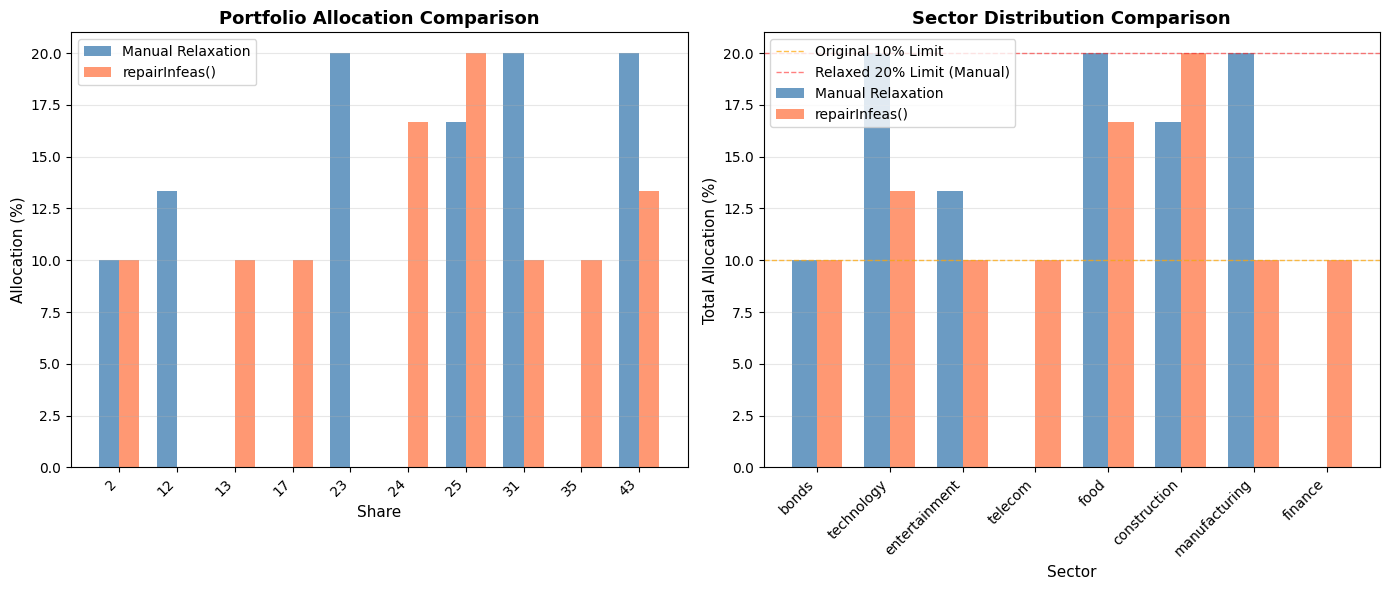

Portfolio Comparison:
  Manual Relaxation - Expected Return: 18.49%
  repairInfeas()    - Expected Return: 15.93%

  Both methods successfully resolved the infeasibility by relaxing sector constraints.

Total sector constraint violation (sum of excesses above original 10% limit):
  Sector                   Manual  repairInfeas
  --------------------------------------------
  technology                10.0%          3.3%
  entertainment              3.3%          0.0%
  food                      10.0%          6.7%
  construction               6.7%         10.0%
  manufacturing             10.0%          0.0%
  --------------------------------------------
  Total violation           40.0%         20.0%

  repairWeightedInfeas minimises total violation; manual relaxation trades more violation for a better return.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Use the stored solutions from both examples
# sol_example2 and sol_example3 are NumPy arrays with values

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ===== Plot 1: Portfolio Allocation by Share =====
# Get shares that appear in either solution
shares_in_sol = set()
for i, share in enumerate(Shares.index):
    if sol_example2[i] > 0.001 or sol_example3[i] > 0.001:
        shares_in_sol.add(share)

shares_list = sorted(shares_in_sol)
x_pos = np.arange(len(shares_list))
width = 0.35

# Get allocations for selected shares
alloc_ex2 = [sol_example2[list(Shares.index).index(s)] * 100 for s in shares_list]
alloc_ex3 = [sol_example3[list(Shares.index).index(s)] * 100 for s in shares_list]

bars1 = ax1.bar(x_pos - width/2, alloc_ex2, width, label='Manual Relaxation', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, alloc_ex3, width, label='repairInfeas()', color='coral', alpha=0.8)

ax1.set_xlabel('Share', fontsize=11)
ax1.set_ylabel('Allocation (%)', fontsize=11)
ax1.set_title('Portfolio Allocation Comparison', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(shares_list, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# ===== Plot 2: Sector Distribution =====
# Calculate sector allocations for both solutions using Pandas
sector_ex2 = {}
sector_ex3 = {}

for sector in SECTORS:
    sector_mask = Shares['Sector'] == sector
    sector_ex2[sector] = (sol_example2[sector_mask.values]).sum() * 100
    sector_ex3[sector] = (sol_example3[sector_mask.values]).sum() * 100

# Filter out sectors with zero allocation in both
active_sectors = [s for s in SECTORS if sector_ex2[s] > 0.1 or sector_ex3[s] > 0.1]
x_pos2 = np.arange(len(active_sectors))

alloc_sec_ex2 = [sector_ex2[s] for s in active_sectors]
alloc_sec_ex3 = [sector_ex3[s] for s in active_sectors]

bars3 = ax2.bar(x_pos2 - width/2, alloc_sec_ex2, width, label='Manual Relaxation', color='steelblue', alpha=0.8)
bars4 = ax2.bar(x_pos2 + width/2, alloc_sec_ex3, width, label='repairInfeas()', color='coral', alpha=0.8)

# Add horizontal lines for original and relaxed sector limits
ax2.axhline(y=10, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Original 10% Limit')
ax2.axhline(y=20, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Relaxed 20% Limit (Manual)')

ax2.set_xlabel('Sector', fontsize=11)
ax2.set_ylabel('Total Allocation (%)', fontsize=11)
ax2.set_title('Sector Distribution Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos2)
ax2.set_xticklabels(active_sectors, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison summary using Pandas vectorized operations
obj_ex2 = (Shares['Return'] * sol_example2).sum()
obj_ex3 = (Shares['Return'] * sol_example3).sum()

print(f"Portfolio Comparison:")
print(f"  Manual Relaxation - Expected Return: {obj_ex2:.2f}%")
print(f"  repairInfeas()    - Expected Return: {obj_ex3:.2f}%")
print(f"\n  Both methods successfully resolved the infeasibility by relaxing sector constraints.")


# Total weighted violation: sum of sector excesses above original 10% limit
original_max_sector = 0.10
print(f"\nTotal sector constraint violation (sum of excesses above original 10% limit):")
viol_header = f"  {'Sector':<20} {'Manual':>10}  {'repairInfeas':>12}"
print(viol_header)
print("  " + "-" * 44)
total_viol_ex2 = 0.0
total_viol_ex3 = 0.0
for s in SECTORS:
    v2 = max(0, sector_ex2[s]/100 - original_max_sector)
    v3 = max(0, sector_ex3[s]/100 - original_max_sector)
    total_viol_ex2 += v2
    total_viol_ex3 += v3
    if v2 > 0 or v3 > 0:
        print(f"  {s:<20} {v2*100:>9.1f}%  {v3*100:>11.1f}%")
print("  " + "-" * 44)
print(f"  {'Total violation':<20} {total_viol_ex2*100:>9.1f}%  {total_viol_ex3*100:>11.1f}%")
print(f"\n  repairWeightedInfeas minimises total violation; manual relaxation trades more violation for a better return.")